In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

ipl = pd.read_csv("IPL_ball_by_ball_updated.csv")

print("IPL dataset loaded successfully.")
print("Shape:", ipl.shape)
print("Columns:", len(ipl.columns))

IPL dataset loaded successfully.
Shape: (243815, 22)
Columns: 22


In [2]:
print("Columns:")
print(ipl.columns.tolist())

print("\nFirst five records:")
display(ipl.head())

Columns:
['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']

First five records:


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Missing-value count by column:")
missing_values = ipl.isnull().sum()
display(missing_values.to_frame("Missing Values"))

print("Total missing values:", int(missing_values.sum()))

Missing-value count by column:


,Missing Values
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


Total missing values: 2157123


In [4]:
ipl_clean = ipl.copy()

numeric_cols = ipl_clean.select_dtypes(include=np.number).columns
categorical_cols = ipl_clean.select_dtypes(include=["object", "category"]).columns

for col in numeric_cols:
    if ipl_clean[col].isnull().any():
        ipl_clean[col] = ipl_clean[col].fillna(ipl_clean[col].mean())

for col in categorical_cols:
    if ipl_clean[col].isnull().any():
        mode_value = ipl_clean[col].mode()
        if not mode_value.empty:
            ipl_clean[col] = ipl_clean[col].fillna(mode_value.iloc[0])

print("Total missing values before:", int(ipl.isnull().sum().sum()))
print("Total missing values after:", int(ipl_clean.isnull().sum().sum()))

Total missing values before: 2157123
Total missing values after: 487630


In [5]:
comparison = pd.DataFrame({
    "Before Cleaning": ipl.isnull().sum(),
    "After Cleaning": ipl_clean.isnull().sum()
})
display(comparison)

,Before Cleaning,After Cleaning
match_id,0,0
season,0,0
start_date,0,0
venue,0,0
innings,0,0
ball,0,0
batting_team,0,0
bowling_team,0,0
striker,0,0
non_striker,0,0


In [6]:
duplicate_count = int(ipl_clean.duplicated().sum())
print("Duplicate rows before removal:", duplicate_count)

ipl_clean = ipl_clean.drop_duplicates().copy()

print("Duplicate rows after removal:", int(ipl_clean.duplicated().sum()))
print("Cleaned dataset shape:", ipl_clean.shape)

Duplicate rows before removal: 0


Duplicate rows after removal: 0
Cleaned dataset shape: (243815, 22)


In [7]:
outlier_col = "runs_off_bat"

q1 = ipl[outlier_col].quantile(0.25)
q3 = ipl[outlier_col].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = ipl[(ipl[outlier_col] < lower) | (ipl[outlier_col] > upper)]

print("Column selected:", outlier_col)
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of outliers:", len(outliers))

display(outliers.head(10))

Column selected: runs_off_bat
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower limit: -1.5
Upper limit: 2.5
Number of outliers: 40280


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
8,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,1.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,Z Khan,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,1.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,Z Khan,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,1.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,Z Khan,6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,1.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,Z Khan,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,2.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,3.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,AA Noffke,6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,3.4,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,AA Noffke,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,3.7,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,AA Noffke,6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,4.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,4.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


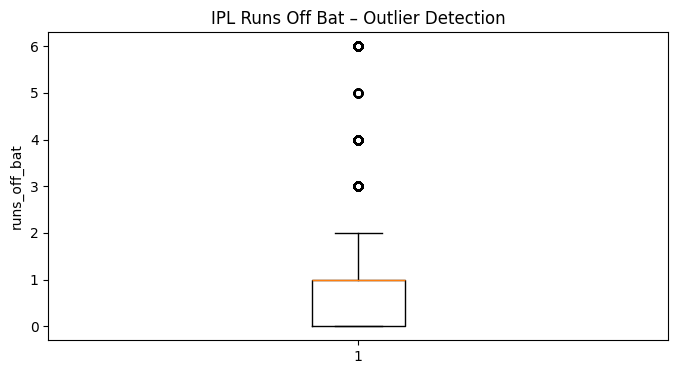

In [8]:
plt.figure(figsize=(8, 4))
plt.boxplot(ipl[outlier_col].dropna())
plt.title("IPL Runs Off Bat – Outlier Detection")
plt.ylabel("runs_off_bat")
plt.show()

In [9]:
scaler = MinMaxScaler()
ipl_transformed = ipl_clean.copy()

ipl_transformed["runs_off_bat_normalized"] = scaler.fit_transform(
    ipl_transformed[["runs_off_bat"]]
)

display(ipl_transformed[["runs_off_bat", "runs_off_bat_normalized"]].head(10))

print("Minimum normalized value:", ipl_transformed["runs_off_bat_normalized"].min())
print("Maximum normalized value:", ipl_transformed["runs_off_bat_normalized"].max())

,runs_off_bat,runs_off_bat_normalized
0,0,0.000000
1,0,0.000000
2,0,0.000000
3,0,0.000000
4,0,0.000000
5,0,0.000000
6,0,0.000000
7,0,0.000000
8,4,0.666667
9,4,0.666667


Minimum normalized value: 0.0
Maximum normalized value: 1.0


In [10]:
encoder = LabelEncoder()
ipl_transformed["batting_team_encoded"] = encoder.fit_transform(
    ipl_transformed["batting_team"].astype(str)
)

print("Column encoded: batting_team")
print("Number of categories:", len(encoder.classes_))
print("First five category mappings:")
print(dict(zip(encoder.classes_[:5], encoder.transform(encoder.classes_[:5]))))

display(
    ipl_transformed[["batting_team", "batting_team_encoded"]].drop_duplicates()
    .sort_values("batting_team_encoded").head(10)
)

Column encoded: batting_team
Number of categories: 18
First five category mappings:
{'Chennai Super Kings': np.int64(0), 'Deccan Chargers': np.int64(1), 'Delhi Capitals': np.int64(2), 'Delhi Daredevils': np.int64(3), 'Gujarat Lions': np.int64(4)}


,batting_team,batting_team_encoded
225,Chennai Super Kings,0
938,Deccan Chargers,1
165203,Delhi Capitals,2
595,Delhi Daredevils,3
123043,Gujarat Lions,4
208894,Gujarat Titans,5
349,Kings XI Punjab,6
42073,Kochi Tuskers Kerala,7
0,Kolkata Knight Riders,8
208770,Lucknow Super Giants,9


In [11]:
one_hot = pd.get_dummies(
    ipl_clean[["batting_team"]].astype(str),
    prefix="batting_team"
)

print("One-hot encoded shape:", one_hot.shape)
display(one_hot.head(10))

One-hot encoded shape: (243815, 18)


,batting_team_Chennai Super Kings,batting_team_Deccan Chargers,batting_team_Delhi Capitals,batting_team_Delhi Daredevils,batting_team_Gujarat Lions,batting_team_Gujarat Titans,batting_team_Kings XI Punjab,batting_team_Kochi Tuskers Kerala,batting_team_Kolkata Knight Riders,batting_team_Lucknow Super Giants,batting_team_Mumbai Indians,batting_team_Pune Warriors,batting_team_Punjab Kings,batting_team_Rajasthan Royals,batting_team_Rising Pune Supergiant,batting_team_Rising Pune Supergiants,batting_team_Royal Challengers Bangalore,batting_team_Sunrisers Hyderabad
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [12]:
summary = pd.DataFrame([{
    "Original Rows": len(ipl),
    "Cleaned Rows": len(ipl_clean),
    "Duplicate Rows Removed": duplicate_count,
    "Missing Values Before": int(ipl.isnull().sum().sum()),
    "Missing Values After": int(ipl_clean.isnull().sum().sum()),
    "Outlier Column": outlier_col,
    "Outliers Detected": int(len(outliers)),
    "Normalized Column": "runs_off_bat",
    "Encoded Column": "batting_team"
}])

display(summary)

,Original Rows,Cleaned Rows,Duplicate Rows Removed,Missing Values Before,Missing Values After,Outlier Column,Outliers Detected,Normalized Column,Encoded Column
0,243815,243815,0,2157123,487630,runs_off_bat,40280,runs_off_bat,batting_team
